# Escala de sustentabilidade local

Este notebook compila em memória o projeto Synesis **DSAP - Vila dos Coqueiros** com `synesis.load` e calcula a escala de sustentabilidade descrita na documentação.

Abra este arquivo no VSCode e selecione um kernel Python com `pandas` e `matplotlib` instalados.

## 1. Carregar o projeto com `synesis.load`

A busca relativa permite executar o notebook tanto a partir da pasta do case study quanto da raiz do repositório `case-studies`. A API compila os arquivos em memória, sem depender de uma exportação intermediária.

In [1]:
from pathlib import Path
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import synesis
from IPython.display import display


def localizar_projeto(inicio: Path) -> Path:
    for base in (inicio, *inicio.parents):
        candidatos = (
            base,
            base / "Socioenvironmental/DSAP_Vila_dos_Coqueiros",
        )
        for candidato in candidatos:
            if (candidato / "project.synp").is_file():
                return candidato
    raise FileNotFoundError("Diretório do projeto DSAP não encontrado.")


def ler_texto(caminho: Path) -> str:
    return caminho.read_text(encoding="utf-8")


projeto = localizar_projeto(Path.cwd())
resultado = synesis.load(
    project_content=ler_texto(projeto / "project.synp"),
    template_content=ler_texto(projeto / "template.synt"),
    annotation_contents={"annotations.syn": ler_texto(projeto / "annotations.syn")},
    ontology_contents={"ontology.syno": ler_texto(projeto / "ontology.syno")},
    bibliography_content=ler_texto(projeto / "references.bib"),
    project_filename="project.synp",
    template_filename="template.synt",
)
assert resultado.success, f"Erro de compilação:\n{resultado.get_diagnostics()}"
dados = resultado.to_json_dict()
print(f"Projeto compilado em memória: {projeto}")
print(dados["export_metadata"])


Projeto compilado em memória: d:\GitHub\case-studies\Socioenvironmental\DSAP_Vila_dos_Coqueiros
{'timestamp': '2026-06-02T02:33:44.904679+00:00', 'compiler_version': '1.1', 'export_mode': 'universal', 'chain_count': 0, 'item_count': 6, 'source_count': 3, 'concept_count': 6}


## 2. Organizar os fatores codificados

Cada item possui um fator, uma categoria SWOT, uma importância e uma dimensão de sustentabilidade vinculada pela ontologia.

In [2]:
rotulos_swot = {
    "fo": "Força",
    "op": "Oportunidade",
    "fr": "Fraqueza",
    "am": "Ameaça",
}

registros = []
for item in dados["corpus"]:
    item_data = item["data"]
    for fator in item_data["fator"]:
        registros.append({
            "fator": fator,
            "swot": rotulos_swot[item_data["swot"]],
            "dimensão": item_data["dimensão_sustentabilidade"],
            "importância": float(item_data["importância"]),
            "fonte": item["source_ref"],
        })

fatores = pd.DataFrame(registros)
fatores


,fator,swot,dimensão,importância,fonte
0,Pesca_Artesanal,Força,econômica,1.0,@oficina_coqueiros2026
1,Descarte_Residuos,Fraqueza,ambiental,0.5,@oficina_coqueiros2026
2,Patrimonio_Cultural,Força,sociocultural,0.5,@oficina_coqueiros2026
3,Saneamento_Basico,Fraqueza,governamental,1.0,@oficina_coqueiros2026
4,Turismo_Comunitario,Oportunidade,econômica,1.0,@jornal_litoral2026
5,Assoreamento,Ameaça,ambiental,1.0,@relatorio_ambiental2025


## 3. Calcular a escala

$$\text{Escala} = \frac{(F + O) - (Fr + A)}{(F + O) + (Fr + A)} \times 5 + 5$$

In [3]:
ordem_swot = ["Força", "Oportunidade", "Fraqueza", "Ameaça"]
totais_swot = fatores.groupby("swot")["importância"].sum().reindex(ordem_swot, fill_value=0.0)

F = totais_swot["Força"]
O = totais_swot["Oportunidade"]
Fr = totais_swot["Fraqueza"]
A = totais_swot["Ameaça"]
denominador = (F + O) + (Fr + A)
if denominador == 0:
    raise ValueError("A escala exige ao menos um fator com importância maior que zero.")

escala = ((F + O) - (Fr + A)) / denominador * 5 + 5


def classe_escala(valor: float) -> str:
    if valor <= 2.50:
        return "Muito desfavorável"
    if valor <= 4.25:
        return "Desfavorável"
    if valor <= 5.75:
        return "Estagnação"
    if valor <= 7.50:
        return "Favorável"
    return "Muito favorável"


classe = classe_escala(escala)
display(totais_swot.rename("Importância acumulada").to_frame())
print(f"Escala de sustentabilidade: {escala:.1f} / 10")
print(f"Classe: {classe}")


,Importância acumulada
swot,
Força,1.5
Oportunidade,1.0
Fraqueza,1.5
Ameaça,1.0


Escala de sustentabilidade: 5.0 / 10
Classe: Estagnação


## 4. Visualizar a escala de sustentabilidade

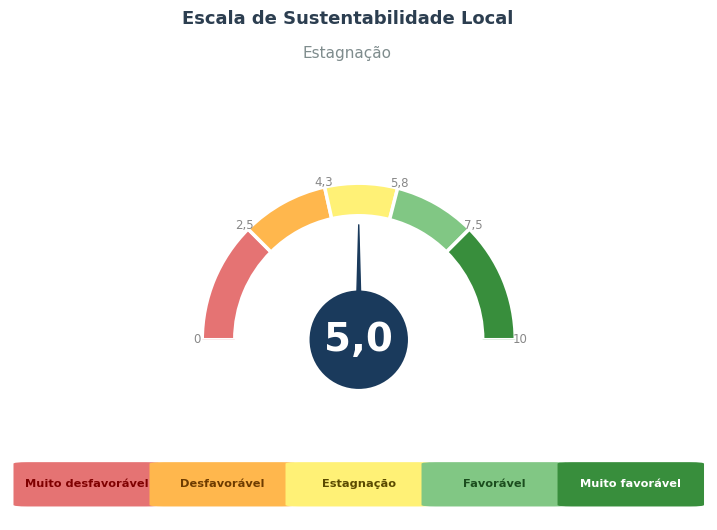

In [4]:
faixas = [
    {"label": "Muito desfavorável", "inicio": 0.0, "fim": 2.5, "cor": "#E57373", "txt": "#7f0000"},
    {"label": "Desfavorável", "inicio": 2.5, "fim": 4.3, "cor": "#FFB74D", "txt": "#6d3b00"},
    {"label": "Estagnação", "inicio": 4.3, "fim": 5.8, "cor": "#FFF176", "txt": "#5a4a00"},
    {"label": "Favorável", "inicio": 5.8, "fim": 7.5, "cor": "#81C784", "txt": "#1b4d1e"},
    {"label": "Muito favorável", "inicio": 7.5, "fim": 10.0, "cor": "#388E3C", "txt": "#ffffff"},
]


def valor_para_rad(valor: float) -> float:
    return np.pi - (valor / 10) * np.pi


fig = plt.figure(figsize=(9, 6), facecolor="white")
gs = gridspec.GridSpec(2, 1, height_ratios=[5, 1], hspace=0.05)
ax = fig.add_subplot(gs[0], projection="polar")
ax.set_facecolor("white")

for faixa in faixas:
    theta_ini = valor_para_rad(faixa["fim"])
    largura = valor_para_rad(faixa["inicio"]) - valor_para_rad(faixa["fim"])
    ax.bar(x=theta_ini, width=largura, height=0.52, bottom=1.98, color=faixa["cor"], edgecolor="white", linewidth=2.5, align="edge")

for valor in [0, 2.5, 4.3, 5.8, 7.5, 10]:
    ax.annotate(f"{valor:g}".replace(".", ","), xy=(valor_para_rad(valor), 2.58), ha="center", va="center", fontsize=8.5, color="#888888")

ax.annotate("", xytext=(0, 0), xy=(valor_para_rad(escala), 1.88), arrowprops=dict(arrowstyle="wedge,tail_width=0.45", color="#1A3A5C", shrinkA=0))
ax.annotate(f"{escala:.1f}".replace(".", ","), xy=(0, 0), xycoords="data", ha="center", va="center", fontsize=28, fontweight="bold", color="white", bbox=dict(boxstyle="circle,pad=0.38", facecolor="#1A3A5C", linewidth=0))
ax.set_ylim(0, 3)
ax.set_xlim(0, np.pi)
ax.set_axis_off()

fig.text(0.5, 0.96, "Escala de Sustentabilidade Local", ha="center", va="top", fontsize=13, fontweight="bold", color="#2C3E50")
fig.text(0.5, 0.90, classe, ha="center", va="top", fontsize=11, color="#7F8C8D")

ax2 = fig.add_subplot(gs[1])
ax2.set_axis_off()
chip_w, chip_h = 0.17, 0.55
gap = (1.0 - len(faixas) * chip_w) / (len(faixas) + 1)
for indice, faixa in enumerate(faixas):
    x = gap + indice * (chip_w + gap)
    chip = mpatches.FancyBboxPatch((x, 0.2), chip_w, chip_h, boxstyle="round,pad=0.02", facecolor=faixa["cor"], edgecolor="none", transform=ax2.transAxes, clip_on=False)
    ax2.add_patch(chip)
    ax2.text(x + chip_w / 2, 0.2 + chip_h / 2, faixa["label"], ha="center", va="center", fontsize=8.2, fontweight="bold", color=faixa["txt"], transform=ax2.transAxes)

plt.show()


## 5. Resumos complementares

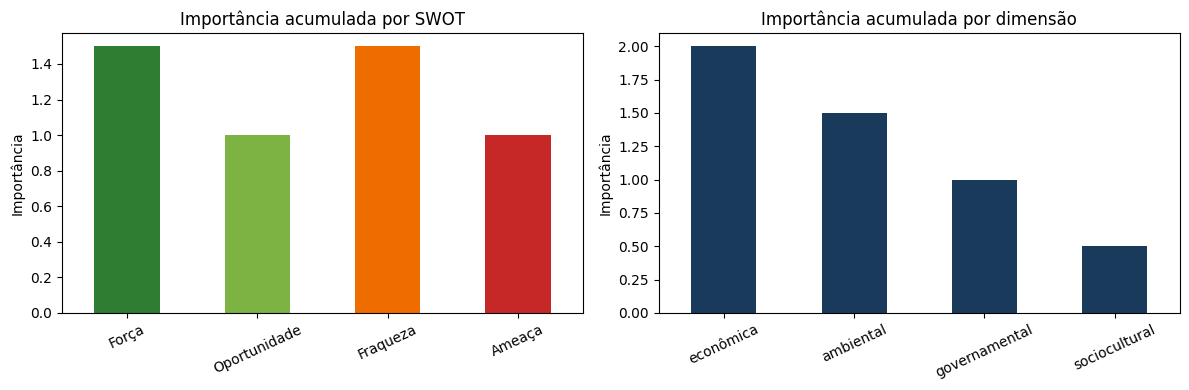

In [5]:
cores_swot = {
    "Força": "#2E7D32",
    "Oportunidade": "#7CB342",
    "Fraqueza": "#EF6C00",
    "Ameaça": "#C62828",
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
totais_swot.plot.bar(ax=axes[0], color=[cores_swot[item] for item in totais_swot.index], title="Importância acumulada por SWOT")
axes[0].set_xlabel("")
axes[0].set_ylabel("Importância")
axes[0].tick_params(axis="x", rotation=25)

totais_dimensao = fatores.groupby("dimensão")["importância"].sum().sort_values(ascending=False)
totais_dimensao.plot.bar(ax=axes[1], color="#1A3A5C", title="Importância acumulada por dimensão")
axes[1].set_xlabel("")
axes[1].set_ylabel("Importância")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()
